In [15]:
from pathlib import Path
import shutil
import pycolmap

import numpy as np
import matplotlib.pyplot as plt

from hloc import visualization

In [2]:
output_path   = Path("example/")
image_path    = Path("Horse/")
database_path = output_path / "database.db"
sfm_path      = output_path / "sfm"

output_path.mkdir(exist_ok=True)

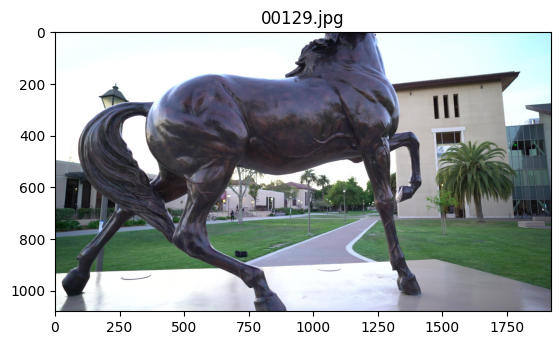

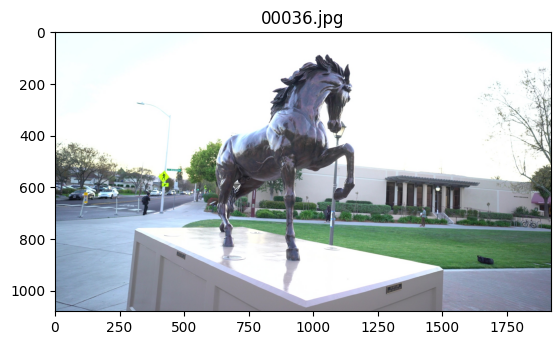

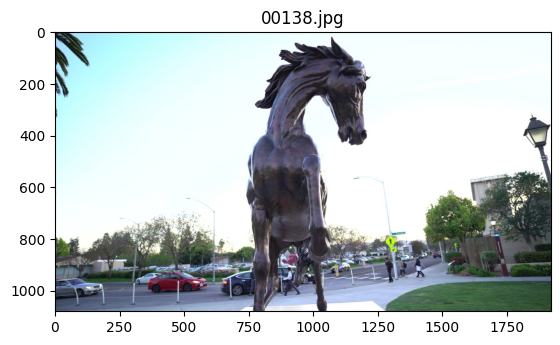

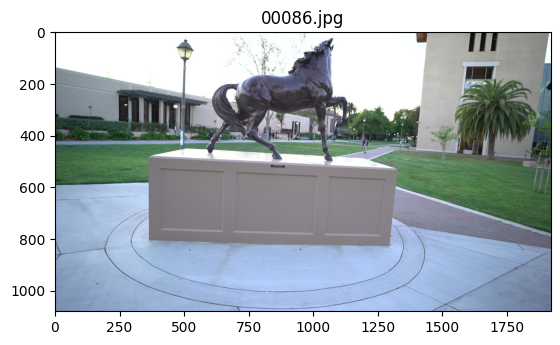

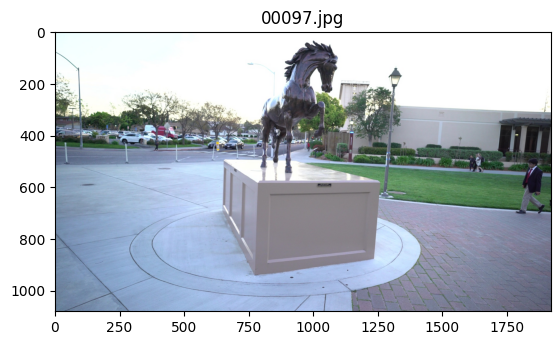

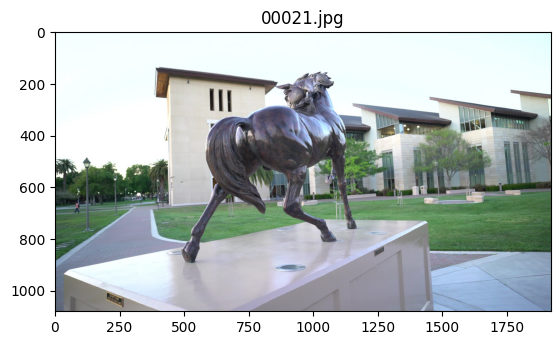

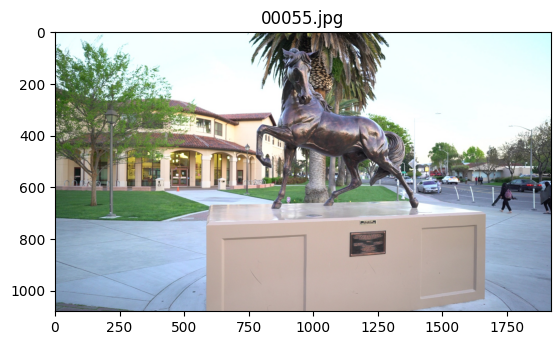

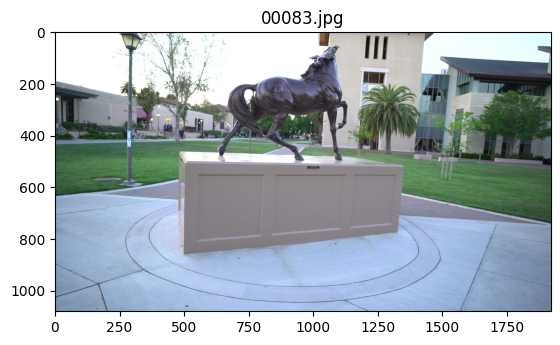

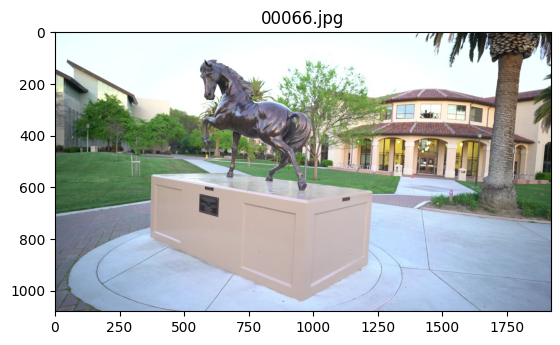

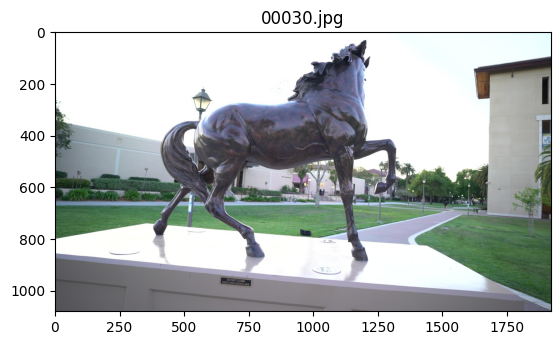

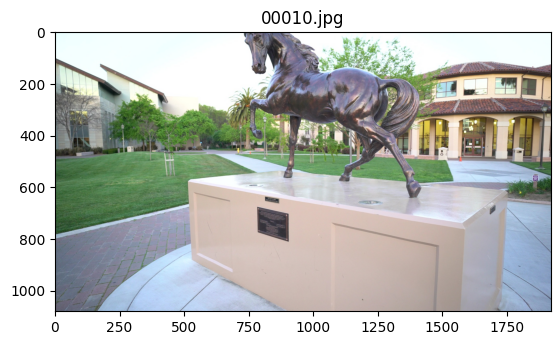

In [3]:
for i, path in enumerate(image_path.glob("*")):
    img = plt.imread(path)
    plt.imshow(img)
    plt.title(path.name)
    plt.show()
    if i > 9:
        break

In [4]:
if not database_path.exists():
    reader_opts = pycolmap.ImageReaderOptions(camera_model="OPENCV")
    sift_opts = pycolmap.SiftExtractionOptions()
    device    = pycolmap.Device.auto
    pycolmap.extract_features(database_path, image_path, reader_options=reader_opts, sift_options=sift_opts, device=device)
    pycolmap.match_exhaustive(database_path, )

In [5]:
db = pycolmap.Database(database_path)

1705


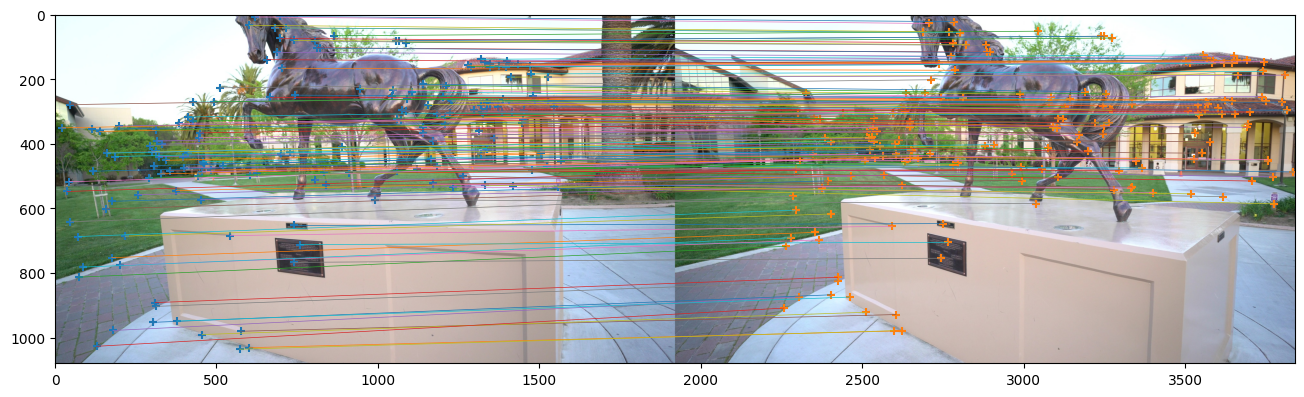

In [6]:
img_ids = [10, 14]
img1 = db.read_image(img_ids[0])
img2 = db.read_image(img_ids[1])

a = plt.imread(image_path / img1.name)
b = plt.imread(image_path / img2.name)
cat = np.hstack([a, b])
plt.figure(figsize=(16, 9))
plt.imshow(cat)

K = 10
matches = db.read_matches(*img_ids)
mk = matches[::K]
kp1 = db.read_keypoints(img_ids[0])[:, [0, 1]] # get just coordinates
kp2 = db.read_keypoints(img_ids[1])[:, [0, 1]]

plt.scatter(kp1[mk[:, 0], 0], kp1[mk[:, 0], 1], marker="+")
plt.scatter(kp2[mk[:, 1], 0] + a.shape[1], kp2[mk[:, 1], 1], marker="+")

for m1, m2 in mk:
    x, y = kp1[m1]
    u, v = kp2[m2]
    plt.plot([x, u + a.shape[1]], [y, v], lw=0.5)
print(len(matches))

In [7]:
res = pycolmap.estimate_fundamental_matrix(kp1[matches[:, 0]], kp2[matches[:, 1]])
res["F"], res["num_inliers"]

(array([[ 3.98333034e-07,  1.66306481e-06, -2.71617030e-03],
        [-2.05110542e-07, -7.75342900e-08, -8.08457369e-03],
        [ 1.78408592e-03,  6.36745337e-03,  9.99941766e-01]]),
 1688)

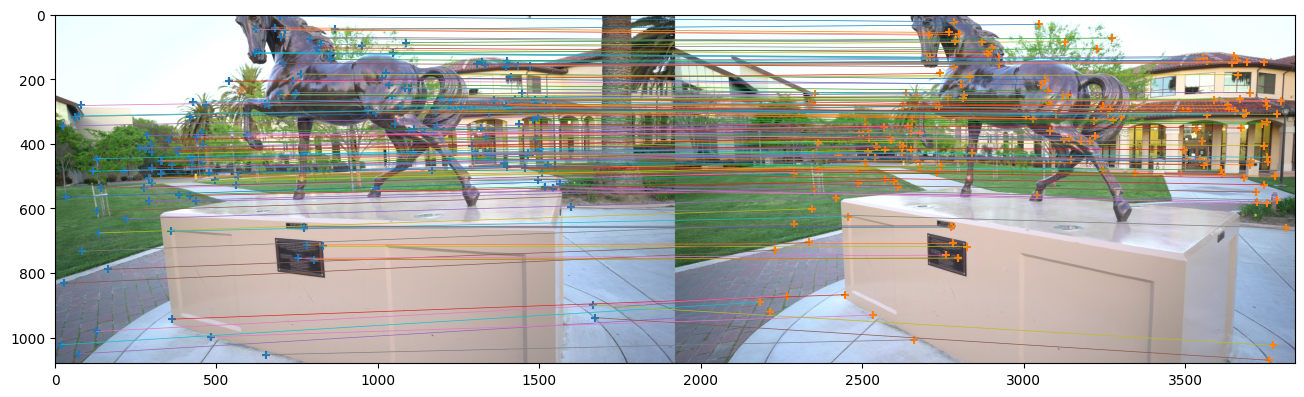

In [8]:
inliers = matches[res["inlier_mask"]]
plt.figure(figsize=(16, 9))
plt.imshow(cat)
plt.scatter(kp1[inliers[::K, 0], 0], kp1[inliers[::K, 0], 1], marker="+")
plt.scatter(kp2[inliers[::K, 1], 0] + a.shape[1], kp2[inliers[::K, 1], 1], marker="+")

for m1, m2 in inliers[::K]:
    x, y = kp1[m1]
    u, v = kp2[m2]
    plt.plot([x, u + a.shape[1]], [y, v], lw=0.5)

In [9]:
recs = pycolmap.incremental_mapping(database_path, image_path, sfm_path,)

I20250806 19:27:19.541816 140040368538048 incremental_pipeline.cc:253] Loading database
I20250806 19:27:19.694668 140040368538048 database_cache.cc:66] Loading rigs...
I20250806 19:27:19.699181 140040368538048 database_cache.cc:76]  0 in 0.005s
I20250806 19:27:19.699192 140040368538048 database_cache.cc:84] Loading cameras...
I20250806 19:27:19.703630 140040368538048 database_cache.cc:102]  1 in 0.004s
I20250806 19:27:19.703637 140040368538048 database_cache.cc:110] Loading frames...
I20250806 19:27:19.710165 140040368538048 database_cache.cc:127]  0 in 0.007s
I20250806 19:27:19.710172 140040368538048 database_cache.cc:135] Loading matches...
I20250806 19:27:26.108041 140040368538048 database_cache.cc:140]  7153 in 6.398s
I20250806 19:27:26.108204 140040368538048 database_cache.cc:156] Loading images...
I20250806 19:27:34.196846 140040368538048 database_cache.cc:241]  151 in 8.089s (connected 151)
I20250806 19:27:34.196937 140040368538048 database_cache.cc:252] Building correspondence 

In [10]:
print(recs[0].summary())

Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 151
	num_reg_frames = 151
	num_images = 151
	num_points3D = 76082
	num_observations = 577648
	mean_track_length = 7.59244
	mean_observations_per_image = 3825.48
	mean_reprojection_error = 0.865003


In [12]:
recs[0].cameras[1]

Camera(camera_id=1, model=SIMPLE_RADIAL, width=1920, height=1080, params=[1157.86, 960, 540, -0.0290208] (f, cx, cy, k))

In [14]:
recs[0].export_PLY(output_path / "model.ply")

In [ ]:
import open3d as o3d
sample_ply_data = o3d.data.PLYPointCloud()
pcd = o3d.io.read_point_cloud(output_path /"model.ply")
o3d.visualization.draw_geometries([pcd],
                                  zoom=1,
                                  front=[0.4257, -0.2125, -0.8795],
                                  lookat=[2.6172, 2.0475, 1.532],
                                  up=[0, -1, 0])


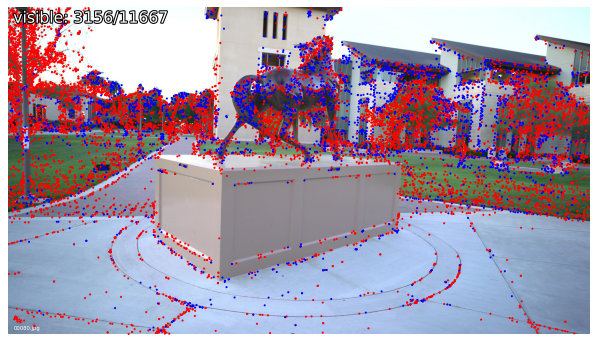

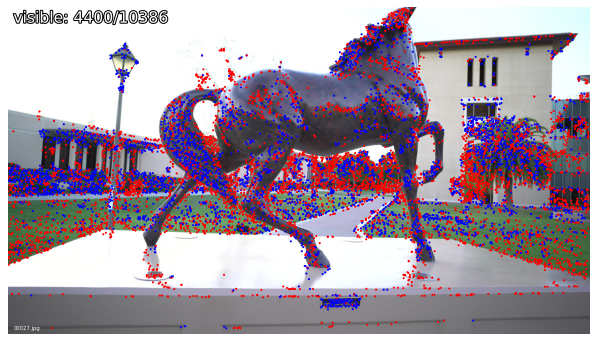

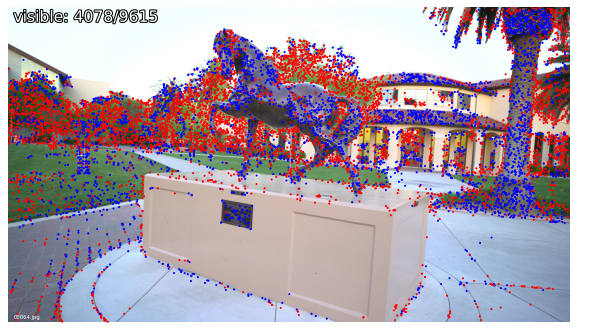

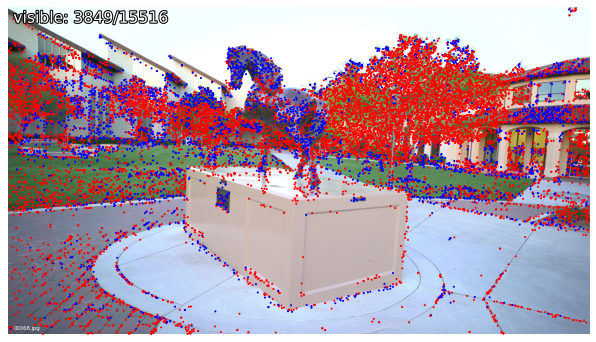

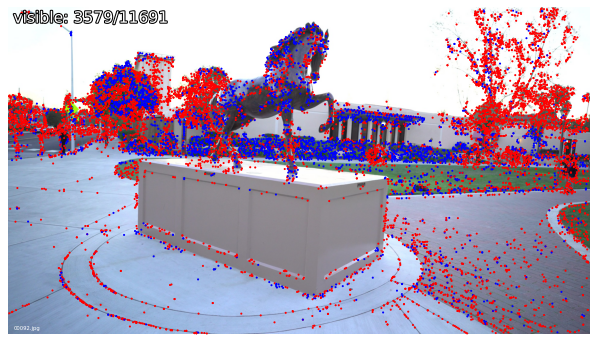

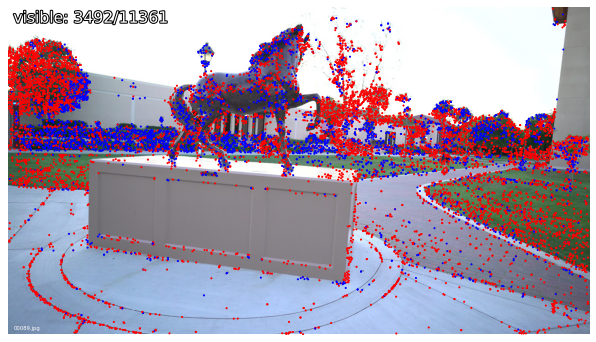

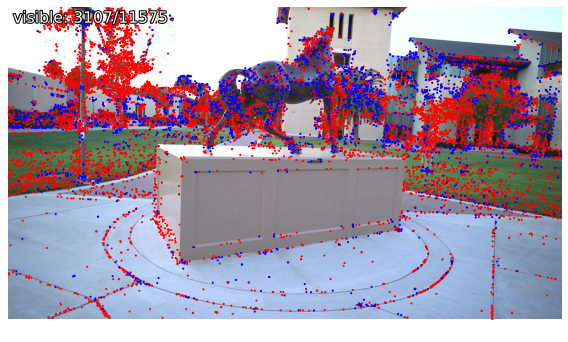

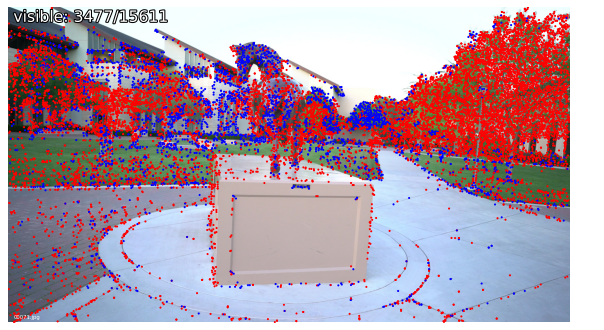

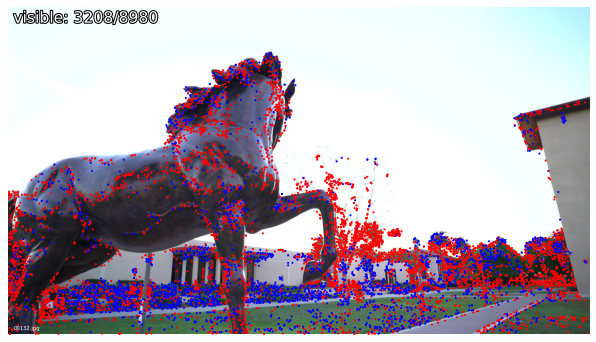

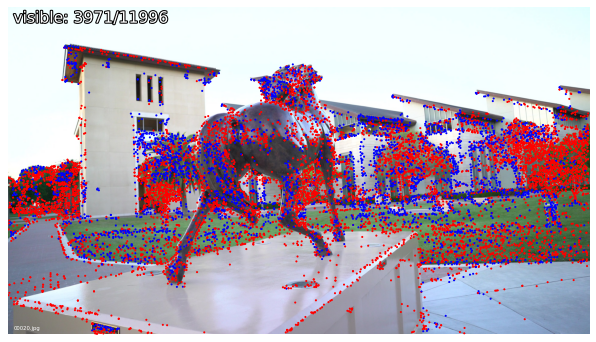

In [17]:
visualization.visualize_sfm_2d(recs[0], image_path, n=10)